In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
file_path = "/content/drive/MyDrive/spam.csv"

In [6]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt


from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv(file_path, encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [9]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [stemmer.stem(w) for w in words]

    return ' '.join(words)

df['text'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [10]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df['text']).toarray()
y = df['label']

Before:
label
0    4825
1     747
Name: count, dtype: int64

After:
label
0    4825
1    4825
Name: count, dtype: int64


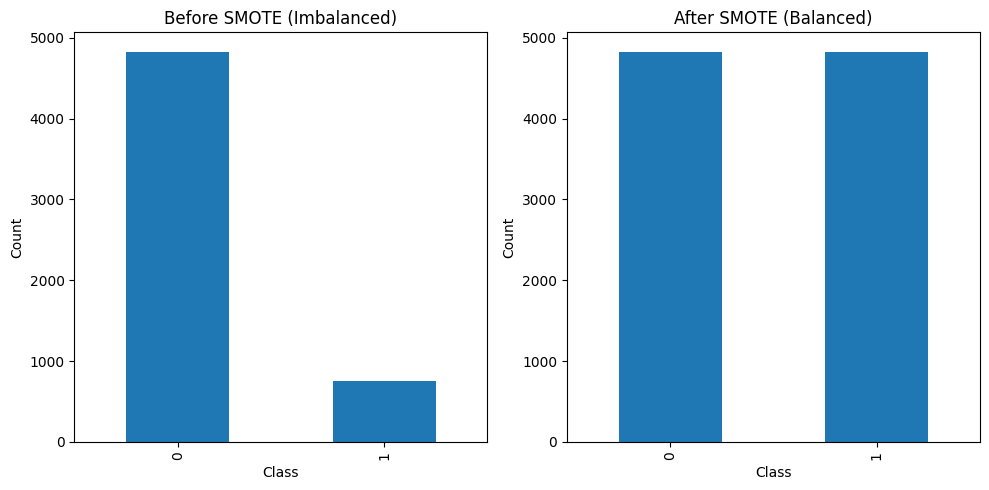

In [11]:
import matplotlib.pyplot as plt

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before:")
print(pd.Series(y).value_counts())

print("\nAfter:")
print(pd.Series(y_resampled).value_counts())


# Before balancing
before_counts = pd.Series(y).value_counts()

# After balancing
after_counts = pd.Series(y_resampled).value_counts()


plt.figure(figsize=(10,5))

# Plot BEFORE
plt.subplot(1,2,1)
before_counts.plot(kind='bar')
plt.title("Before SMOTE (Imbalanced)")
plt.xlabel("Class")
plt.ylabel("Count")

# Plot AFTER
plt.subplot(1,2,2)
after_counts.plot(kind='bar')
plt.title("After SMOTE (Balanced)")
plt.xlabel("Class")
plt.ylabel("Count")

# Show plots
plt.tight_layout()
plt.show()


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9875647668393782
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       985
           1       0.99      0.99      0.99       945

    accuracy                           0.99      1930
   macro avg       0.99      0.99      0.99      1930
weighted avg       0.99      0.99      0.99      1930



In [15]:
def predict_email(text):
    text = preprocess(text)
    vector = vectorizer.transform([text]).toarray()
    result = model.predict(vector)

    return "Spam" if result[0] == 1 else "Not Spam"



print(predict_email("Project submission tomorrow. Win cash now"))
print(predict_email("Your friend shared notes. Also get free entry in competition"))
print(predict_email("Security alert: login detected. Win free protection package"))
print(predict_email("Please send me the assignment file"))
print(predict_email("Click here to win a free iPhone"))


Spam
Not Spam
Spam
Not Spam
Spam


In [27]:
import pickle

pickle.dump(model, open("/content/drive/MyDrive/SpamProject/model.pkl", "wb"))
pickle.dump(vectorizer, open("/content/drive/MyDrive/SpamProject/vectorizer.pkl", "wb"))